


The code predicts two main outcomes based on user activity data:

Engagement Prediction (Regression):

The code uses linear regression to predict the "engagement" of each user. Engagement is defined as the ratio of message counts to total hours spent. The model takes total hours and message counts as input features to estimate this engagement metric.
Activity Level Classification:

The code categorizes user engagement into three levels: 'Low', 'Medium', and 'High' based on defined thresholds. A Random Forest classifier is used to predict these engagement levels from the same features (total hours and message counts).



Most Active User: User1
Total Messages Sent: 200
Total Hours Spent: 976
Most Active Hour for User1: 0:00 with 200 messages
Regression MSE: 3.068101183500049e-08
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         2
         Low       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



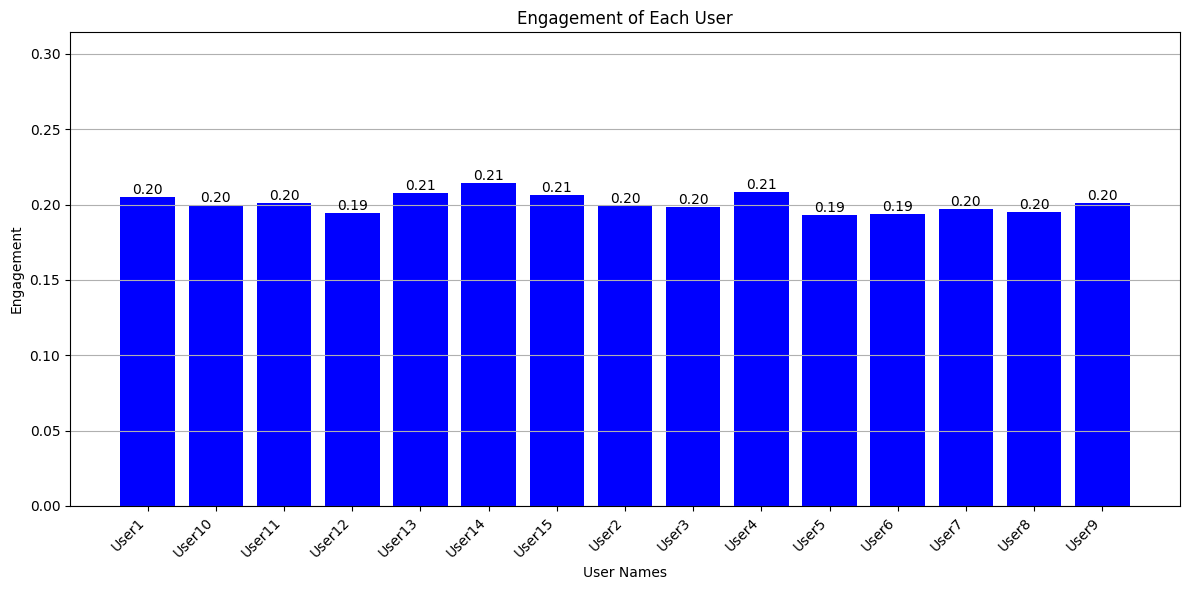

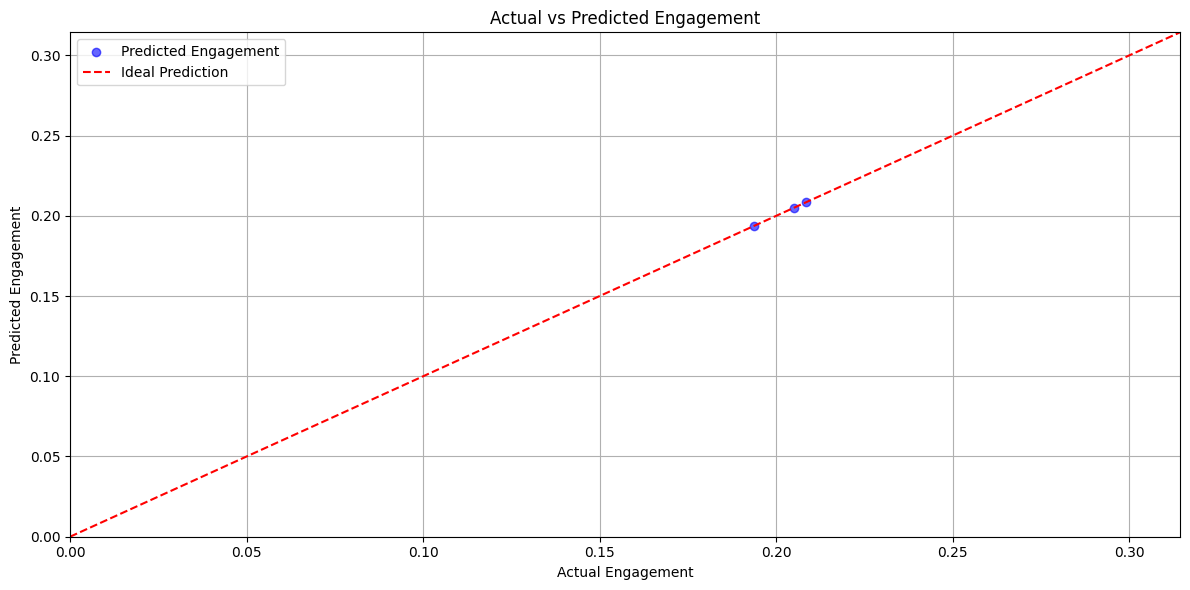

In [ ]:
# final
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, classification_report
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# Step 1: Load the data from wa.csv
def load_data(file_path):
    try:
        df = pd.read_csv(file_path)
        df['timestamp'] = pd.to_datetime(df['timestamp'], format='%d-%m-%Y', dayfirst=True)
        return df
    except Exception as e:
        print(f"Error loading data: {e}")
        exit()

df = load_data('waf.csv')

# Step 2: Aggregate data by user
user_activity = df.groupby('names').agg({
    'hours': 'sum',
    'timestamp': 'count'  # Count number of messages
}).reset_index()

user_activity.columns = ['names', 'total_hours', 'message_count']

# Avoid division by zero
user_activity['engagement'] = user_activity.apply(
    lambda row: row['message_count'] / row['total_hours'] if row['total_hours'] > 0 else 0,
    axis=1
)

# Step 3: Find the most active user
most_active_user_row = user_activity.loc[user_activity['message_count'].idxmax()]
most_active_user = most_active_user_row['names']
total_messages = most_active_user_row['message_count']
total_hours = most_active_user_row['total_hours']

print(f"Most Active User: {most_active_user}")
print(f"Total Messages Sent: {total_messages}")
print(f"Total Hours Spent: {total_hours}")

# Step 4: Analyze hourly activity for the most active user
df['hour'] = df['timestamp'].dt.hour  # Extract the hour from the timestamp
user_hourly_activity = df[df['names'] == most_active_user].groupby('hour').size().reset_index(name='message_count')

# Find the hour with the most messages
most_active_hour_row = user_hourly_activity.loc[user_hourly_activity['message_count'].idxmax()]
most_active_hour = most_active_hour_row['hour']
most_active_hour_count = most_active_hour_row['message_count']

print(f"Most Active Hour for {most_active_user}: {most_active_hour}:00 with {most_active_hour_count} messages")

# Step 5: Regression to predict engagement
X_reg = user_activity[['total_hours', 'message_count']]
y_reg = user_activity['engagement']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Create and train the regression model
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# Make predictions and evaluate the model
y_pred = regressor.predict(X_test)
print(f"Regression MSE: {mean_squared_error(y_test, y_pred)}")

# Step 6: Classification based on engagement
def categorize_engagement(engagement):
    if engagement < 0.20:
        return 'Low'
    elif engagement > 1.0:
        return 'Medium'
    else:
        return 'High'

user_activity['activity_level'] = user_activity['engagement'].apply(categorize_engagement)

# Encode the target variable
label_encoder = LabelEncoder()
y_class = label_encoder.fit_transform(user_activity['activity_level'])

# Split the data for classification
X_class = user_activity[['total_hours', 'message_count']]
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

# Create and train the classification model
classifier = RandomForestClassifier(random_state=42)
classifier.fit(X_train_class, y_train_class)

# Make predictions and evaluate the model
y_pred_class = classifier.predict(X_test_class)
print(classification_report(y_test_class, y_pred_class, target_names=label_encoder.classes_))

# Step 7: Visualize engagement for each user using a bar plot
plt.figure(figsize=(12, 6))
plt.bar(user_activity['names'], user_activity['engagement'], color='blue')

# Add data point labels
for i, row in user_activity.iterrows():
    plt.text(row['names'], row['engagement'], f"{row['engagement']:.2f}", ha='center', va='bottom')

plt.xticks(rotation=45, ha='right')
plt.xlabel('User Names')
plt.ylabel('Engagement')
plt.title('Engagement of Each User')
plt.ylim(0, user_activity['engagement'].max() + 0.1)  # Add some space above the max value
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Step 8: Visualize the regression results
plt.figure(figsize=(12, 6))

# Scatter plot of actual engagement vs predicted engagement
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, label='Predicted Engagement')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Ideal Prediction')  # 45-degree line

plt.xlabel('Actual Engagement')
plt.ylabel('Predicted Engagement')
plt.title('Actual vs Predicted Engagement')
plt.xlim(0, user_activity['engagement'].max() + 0.1)
plt.ylim(0, user_activity['engagement'].max() + 0.1)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()



several classifiers (Random Forest, Logistic Regression, and K-Nearest Neighbors) are defined.
Each model is trained and tested, with accuracy and MSE (for applicable models) calculated.
Detailed classification reports are generated for each model, providing precision, recall, and F1 scores for the classes.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error, classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Step 1: Load the data from wa.csv
def load_data(file_path):
    try:
        df = pd.read_csv(file_path)
        df['timestamp'] = pd.to_datetime(df['timestamp'], format='%d-%m-%Y', dayfirst=True)
        return df
    except Exception as e:
        print(f"Error loading data: {e}")
        exit()

df = load_data('waf1.csv')

# Step 2: Aggregate data by user
user_activity = df.groupby('names').agg({
    'hours': 'sum',
    'timestamp': 'count'  # Count number of messages
}).reset_index()

user_activity.columns = ['names', 'total_hours', 'message_count']
user_activity['engagement'] = user_activity.apply(
    lambda row: row['message_count'] / row['total_hours'] if row['total_hours'] > 0 else 0,
    axis=1
)

# Step 3: Regression to predict engagement
X_reg = user_activity[['total_hours', 'message_count']]
y_reg = user_activity['engagement']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Define regression models
regressors = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso()
}

# Evaluate regression models
for name, model in regressors.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f"{name} MSE: {mse:.4f}")

# Step 6: Classification based on engagement
def categorize_engagement(engagement):
    if engagement < 0.20:
        return 'Low'
    elif engagement < 1.20:
        return 'Medium'
    else:
        return 'High'

user_activity['activity_level'] = user_activity['engagement'].apply(categorize_engagement)
label_encoder = LabelEncoder()
y_class = label_encoder.fit_transform(user_activity['activity_level'])

# Check overall class distribution
class_counts = user_activity['activity_level'].value_counts()
print("Overall class distribution:", class_counts)

# Split the data for classification with stratification
X_class = user_activity[['total_hours', 'message_count']]
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42, stratify=y_class
)

# Check class distribution after splitting
unique_classes, counts = np.unique(y_train_class, return_counts=True)
class_distribution = dict(zip(label_encoder.classes_, counts))

if len(unique_classes) < 2:
    print("Warning: Not enough classes in training data for classification.")
    print("Class distribution in training set:", class_distribution)
else:
    # Define classification models including Logistic Regression and KNN
    classifiers = {
        'Random Forest': RandomForestClassifier(random_state=42),
        'Logistic Regression': LogisticRegression(max_iter=1000),
        'K-Nearest Neighbors': KNeighborsClassifier()
    }

    # Store accuracies and MSE
    accuracy_results = {}
    mse_results = {}

    # Evaluate classification models
    for name, model in classifiers.items():
        model.fit(X_train_class, y_train_class)
        y_pred_class = model.predict(X_test_class)
        accuracy = accuracy_score(y_test_class, y_pred_class)
        accuracy_results[name] = accuracy  # Store accuracy

        # Calculate MSE if the model is Logistic Regression or KNN
        if name in ['Logistic Regression', 'K-Nearest Neighbors']:
            y_pred_class_prob = model.predict_proba(X_test_class)[:, 1]
            mse = mean_squared_error(y_test_class, y_pred_class_prob)
            mse_results[name] = mse
            print(f"{name} MSE: {mse:.4f}")

        print(f"{name} Accuracy: {accuracy:.4f}")
        print(classification_report(y_test_class, y_pred_class, target_names=label_encoder.classes_))

    # Evaluate Random Forest MSE separately
    rf_model = classifiers['Random Forest']
    rf_model.fit(X_train_class, y_train_class)
    rf_y_pred = rf_model.predict(X_test_class)
    rf_mse = mean_squared_error(y_test_class, rf_y_pred)
    mse_results['Random Forest'] = rf_mse
    print(f"Random Forest MSE: {rf_mse:.4f}")

    # Determine the best model
    best_model = max(accuracy_results, key=accuracy_results.get)
    best_accuracy = accuracy_results[best_model]
    print(f"The best classification model is '{best_model}' with an accuracy of {best_accuracy:.4f}.")






Linear Regression MSE: 0.0311
Ridge Regression MSE: 0.0311
Lasso Regression MSE: 0.0586
Overall class distribution: activity_level
Low       751
Medium    249
Name: count, dtype: int64
Random Forest Accuracy: 1.0000
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00       150
      Medium       1.00      1.00      1.00        50

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

Logistic Regression MSE: 0.0013
Logistic Regression Accuracy: 1.0000
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00       150
      Medium       1.00      1.00      1.00        50

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

K-Nearest Neighbors MSE: 0.0000
K-Nearest Neighbors Accuracy:

This code implements a machine learning workflow to analyze user activity data from a CSV file (waf1.csv). It processes timestamps, aggregates user activity to calculate total hours and message counts, and computes an engagement metric. After standardizing features, K-Means clustering is performed, with the silhouette score used to assess cluster quality, followed by Agglomerative Clustering. A Multi-layer Perceptron (MLP) regressor is applied for dimensionality reduction. Several classifiers, including Random Forest, Logistic Regression, and K-Nearest Neighbors, are trained and evaluated, with metrics like accuracy and Mean Squared Error (MSE) calculated, alongside detailed classification reports for performance insights.


K-Means Silhouette Score: 0.5058
Agglomerative Clustering Silhouette Score: 0.4460


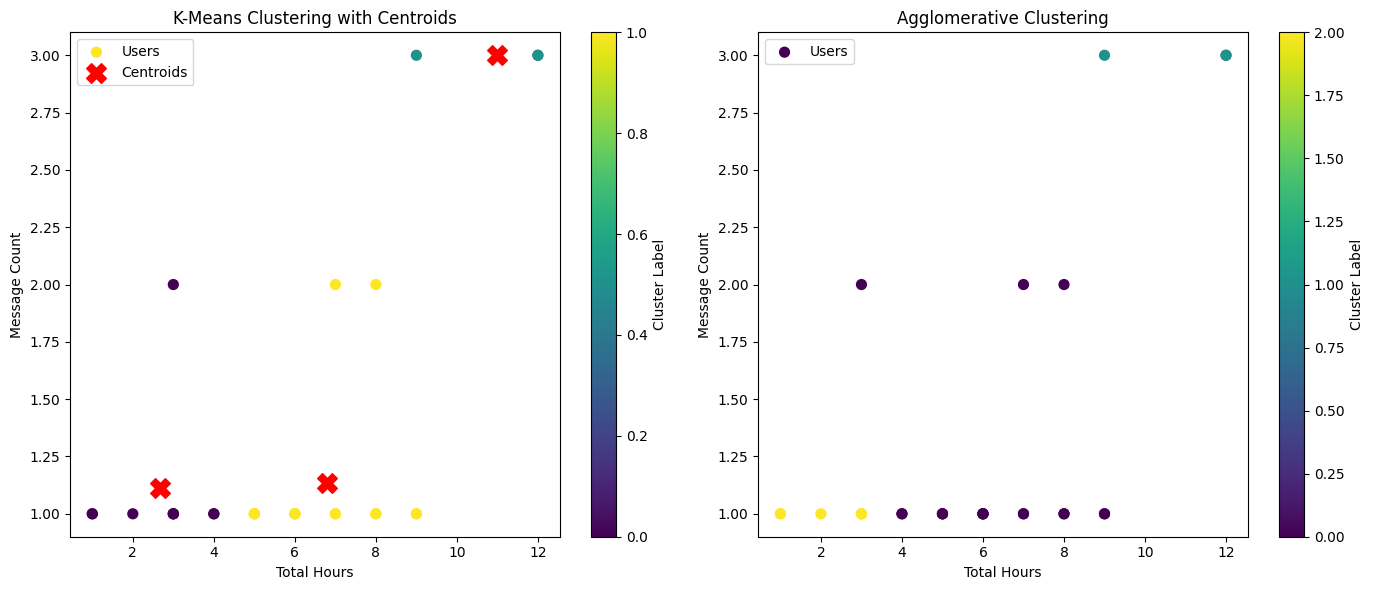

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Function to load data
def load_data(file_path):
    try:
        df = pd.read_csv(file_path)
        df['timestamp'] = pd.to_datetime(df['timestamp'], format='%d-%m-%Y', dayfirst=True)
        return df
    except Exception as e:
        print(f"Error loading data: {e}")
        exit()

df = load_data('waf2.csv')

user_activity = df.groupby('names').agg({
    'hours': 'sum',
    'timestamp': 'count'  # Count number of messages (sessions)
}).reset_index()

user_activity.columns = ['names', 'total_hours', 'message_count']

user_activity['engagement'] = user_activity.apply(
    lambda row: row['message_count'] / row['total_hours'] if row['total_hours'] > 0 else 0,
    axis=1
)

X_clustering = user_activity[['total_hours', 'message_count']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

kmeans = KMeans(n_clusters=3, random_state=42)
user_activity['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

silhouette_kmeans = silhouette_score(X_scaled, user_activity['cluster_kmeans'])
print(f"K-Means Silhouette Score: {silhouette_kmeans:.4f}")

agg_clustering = AgglomerativeClustering(n_clusters=3)
user_activity['cluster_agg'] = agg_clustering.fit_predict(X_scaled)

silhouette_agg = silhouette_score(X_scaled, user_activity['cluster_agg'])
print(f"Agglomerative Clustering Silhouette Score: {silhouette_agg:.4f}")

# Plotting the clusters and centroids
plt.figure(figsize=(14, 6))

# Plot K-Means Clusters and Centroids
plt.subplot(1, 2, 1)
plt.scatter(user_activity['total_hours'], user_activity['message_count'],
            c=user_activity['cluster_kmeans'], cmap='viridis', s=50, label='Users')
# Plot the centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)  # Reverse scaling for centroids
plt.scatter(centroids[:, 0], centroids[:, 1],
            c='red', marker='X', s=200, label='Centroids')
plt.title('K-Means Clustering with Centroids')
plt.xlabel('Total Hours')
plt.ylabel('Message Count')
plt.colorbar(label='Cluster Label')
plt.legend()

# Plot Agglomerative Clustering (without centroids)
plt.subplot(1, 2, 2)
plt.scatter(user_activity['total_hours'], user_activity['message_count'],
            c=user_activity['cluster_agg'], cmap='viridis', s=50, label='Users')
plt.title('Agglomerative Clustering')
plt.xlabel('Total Hours')
plt.ylabel('Message Count')
plt.colorbar(label='Cluster Label')
plt.legend()

plt.tight_layout()
plt.show()
